### Exploratoy Data Analysis

Load dataset

In [419]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

DATASET_FILEPATH = '../data/dataset.csv'
df = pd.read_csv(DATASET_FILEPATH)

#### 1. Dataset descriptives

In [420]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1893 entries, 0 to 1892
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1893 non-null   int64  
 1   make                1893 non-null   object 
 2   model               1893 non-null   object 
 3   year                1893 non-null   float64
 4   body_type           1893 non-null   object 
 5   mileage             1893 non-null   float64
 6   color               1893 non-null   object 
 7   fuel_type           1893 non-null   object 
 8   engine_capacity     1893 non-null   float64
 9   engine_power        1893 non-null   float64
 10  gearbox             1893 non-null   object 
 11  transmission        1893 non-null   object 
 12  pollution_standard  1893 non-null   object 
 13  price               1893 non-null   float64
dtypes: float64(5), int64(1), object(8)
memory usage: 207.2+ KB


In [421]:
df.describe()

,Unnamed: 0,year,mileage,engine_capacity,engine_power,price
count,1893.000000,1893.000000,1893.000000,1893.000000,1893.000000,1893.000000
mean,946.000000,2017.732699,155202.957211,1865.040676,172.443212,20299.769704
std,546.606348,4.083222,76445.088285,512.133517,68.796361,15456.815927
min,0.000000,2006.000000,1000.000000,875.000000,60.000000,1500.000000
25%,473.000000,2015.000000,99200.000000,1498.000000,120.000000,9890.540000
50%,946.000000,2019.000000,157000.000000,1968.000000,150.000000,15988.940000
75%,1419.000000,2021.000000,209230.000000,1996.000000,200.000000,26000.000000
max,1892.000000,2025.000000,395000.000000,3198.000000,400.000000,99000.000000


#### 2. Missing values

In [422]:
print("Missing values per feature:")
print(df.isnull().sum())

Missing values per feature:
Unnamed: 0            0
make                  0
model                 0
year                  0
body_type             0
mileage               0
color                 0
fuel_type             0
engine_capacity       0
engine_power          0
gearbox               0
transmission          0
pollution_standard    0
price                 0
dtype: int64


#### 3. Univariate analysis

In [423]:
numerical_features = [
    "year",
    "mileage",
    "engine_capacity",
    "engine_power",
    "price"
]

categorical_features = [
    "make",
    "model",
    "body_type",
    "color",
    "fuel_type",
    "gearbox",
    "transmission",
    "pollution_standard"
]

##### Helper functions

In [424]:
from matplotlib.ticker import MaxNLocator
def create_boxplot(df, columns, title=None, num_rows=2, figsize=(12, 8)):
    num_plots = len(columns)
    num_cols = (num_plots + num_rows - 1) // num_rows 

    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        ax.boxplot(df[col], vert=True, patch_artist=True)
        
        ax.set_xticks([])
        
        ax.set_xlabel(col, fontsize=12, fontweight='bold')

        if col == 'year':
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        
        ax.tick_params(axis='y', labelsize=12) 
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')
            
    # hide unused subplots
    for ax in axes[num_plots:]:
        ax.axis('off')

    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
    
    plt.show()

def compute_boxplot_stats(df, columns):
    stats = {}
    for col in columns:
        desc = df[col].describe()
        Q1 = desc['25%']
        Q3 = desc['75%']
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        lower_whisker = df[df[col] >= lower_bound][col].min()
        upper_whisker = df[df[col] <= upper_bound][col].max()
        stats[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_whisker': lower_whisker,
            'upper_whisker': upper_whisker,
            'min': desc['min'],
            'max': desc['max'],
            'mean': desc['mean'],
            'stdev': desc['std']
        }
    return pd.DataFrame(stats)

def plot_categorical_feature(df, feature, feature_name=None, figsize=(15, 8), format_func=None, fontsize=12, fontweight='bold', top_n=None, rotation=90):
    full_counts = df[feature].value_counts()
    total_samples = full_counts.sum()
    
    if top_n:
        plot_counts = full_counts.head(top_n)
    else:
        plot_counts = full_counts
        
    plot_cumulative = plot_counts.cumsum() / total_samples * 100
    
    max_reached_pct = plot_cumulative.iloc[-1]

    fig, ax1 = plt.subplots(figsize=figsize)

    plot_counts.plot(kind='bar', ax=ax1, color='purple', width=0.6)

    ax2 = ax1.twinx()
    ax2.plot(range(len(plot_counts)), plot_cumulative, color='red', marker='o', linestyle='-', linewidth=2, markersize=5)

    ax1.set_title(f'Distribution of {f"top {top_n}" if top_n else ""} {feature_name if feature_name else feature}', fontsize=fontsize+4, fontweight=fontweight)

    # left y axis
    ax1.set_ylabel('Count', fontsize=fontsize+2, fontweight=fontweight)
    ax1.tick_params(axis='y', labelsize=fontsize)
    for label in ax1.get_yticklabels():
        label.set_fontweight(fontweight)

    # right y axis (cumulative)
    ax2.set_ylabel('Cumulative % of Total', fontsize=fontsize+2, fontweight=fontweight, color='red')
    
    limit_buffer = max_reached_pct * 0.05 # 5% buffer
    ax2.set_ylim(0, max_reached_pct + limit_buffer)
    
    ax2.tick_params(axis='y', labelsize=fontsize, labelcolor='red')
    for label in ax2.get_yticklabels():
        label.set_fontweight(fontweight)

    ax2.axhline(y=max_reached_pct, color='red', linestyle='--', alpha=0.5)
    ax2.text(len(plot_counts)-1, max_reached_pct + (limit_buffer * 0.2), f'{max_reached_pct:.1f}%', 
             color='red', fontweight='bold', ha='center', va='bottom', fontsize=fontsize)

    # x axis styling
    ax1.tick_params(axis='x', labelsize=fontsize, rotation=rotation)
    for label in ax1.get_xticklabels():
        label.set_fontweight(fontweight)

    ax1.grid(axis='y', alpha=0.3)

    if format_func:
        formatted_labels = [format_func(label) for label in plot_counts.index]
        ax1.set_xticklabels(formatted_labels, ha='right')
    else:
        ax1.set_xticklabels(plot_counts.index, ha='right')
    
    plt.tight_layout()
    ax1.set_xlabel(feature, fontsize=fontsize, fontweight=fontweight)
    plt.show()


def plot_numerical_feature_distribution(df, feature, feature_name, bin_width=10, min_value=None, figsize=(8, 5), format_func=None, fontsize=12, fontweight='bold'):
    plt.figure(figsize=figsize)
    bins = np.arange(min_value if min_value is not None else df[feature].min(), df[feature].max() + bin_width, bin_width)
    plt.hist(df[feature], bins=bins, color='purple')
    plt.title(f'Distribution of {feature_name if feature_name else feature}', fontsize=fontsize, fontweight=fontweight)
    plt.xlabel(feature, fontsize=fontsize, fontweight=fontweight)

    # add an additional parameter which is a function to format the x-axis labels if needed
    if format_func:
        plt.xticks(ticks=bins, labels=[format_func(label) for label in bins], fontsize=fontsize, fontweight=fontweight)

    plt.ylabel('Frequency', fontsize=fontsize, fontweight=fontweight)
    plt.xlabel(feature, fontsize=fontsize, fontweight=fontweight)
    plt.show()

def plot_histograms(df, features, feature_names=None, bins=30, figsize=(15, 10), format_func=None, num_rows=2, color='purple', fontsize=12, fontweight='bold', kde=True):
    import seaborn as sns

    num_plots = len(features)
    num_cols = math.ceil(num_plots / num_rows)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for i, (ax, feature) in enumerate(zip(axes, features)):
        display_name = feature_names[i] if feature_names and i < len(feature_names) else feature

        if kde:
            if feature == 'year':
                sns.histplot(data=df, x=feature, binrange=(2005, 2025), discrete=True, ax=ax, color=color, kde=True)
            else:
                sns.histplot(data=df, x=feature, bins=bins, ax=ax, color=color, kde=True)
        else:
            ax.hist(df[feature], bins=bins, color=color, edgecolor='black', alpha=0.7)

        ax.set_title(f'Distribution of {feature}', fontsize=fontsize, fontweight=fontweight)
        ax.set_xlabel(display_name, fontsize=fontsize, fontweight=fontweight)
        ax.set_ylabel('Frequency', fontsize=fontsize, fontweight=fontweight)
        ax.grid(axis='y', alpha=0.3)

        for label in ax.get_yticklabels():
            label.set_fontweight('bold')

        current_fmt_func = None
        if isinstance(format_func, dict):
            current_fmt_func = format_func.get(feature)
        elif callable(format_func):
            current_fmt_func = format_func
            
        if current_fmt_func:
            ticks = ax.get_xticks()
            ticks = ticks[(ticks >= df[feature].min()) & (ticks <= df[feature].max())]
            ax.set_xticks(ticks, fontsize=fontsize, fontweight=fontweight)
            ax.set_xticklabels([current_fmt_func(t) for t in ticks], rotation=45, ha='right')

    for ax in axes[num_plots:]:
        ax.axis('off')

    plt.show()

def plot_single_histogram(df, feature, figsize=(10, 6), log=False, label=None):
    plt.figure(figsize=figsize)
    series = df[feature]
    if log:
        series = np.log(series)
    plt.hist(series, bins=50, alpha=0.6, color='purple', edgecolor='black', label='Histogram')

    plt.xticks(fontweight='bold', fontsize=10)
    plt.yticks(fontweight='bold', fontsize=10)

    plt.title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    plt.xlabel(label if label else feature, fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_single_boxplot(df, feature, title=None, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.boxplot(df[feature], vert=True, patch_artist=True, 
                boxprops=dict(facecolor="white", color="black"), 
                medianprops=dict(color="red", linewidth=2))

    plt.title(f'{feature} box plot', fontsize=14, fontweight='bold')
    plt.ylabel(title if title else feature, fontsize=12, fontweight='bold')
    
    plt.xticks([]) 
    plt.yticks(fontsize=10, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

##### 3.1 Target variable (price)

count     1893.000000
mean     20299.769704
std      15456.815927
min       1500.000000
25%       9890.540000
50%      15988.940000
75%      26000.000000
max      99000.000000
Name: price, dtype: float64


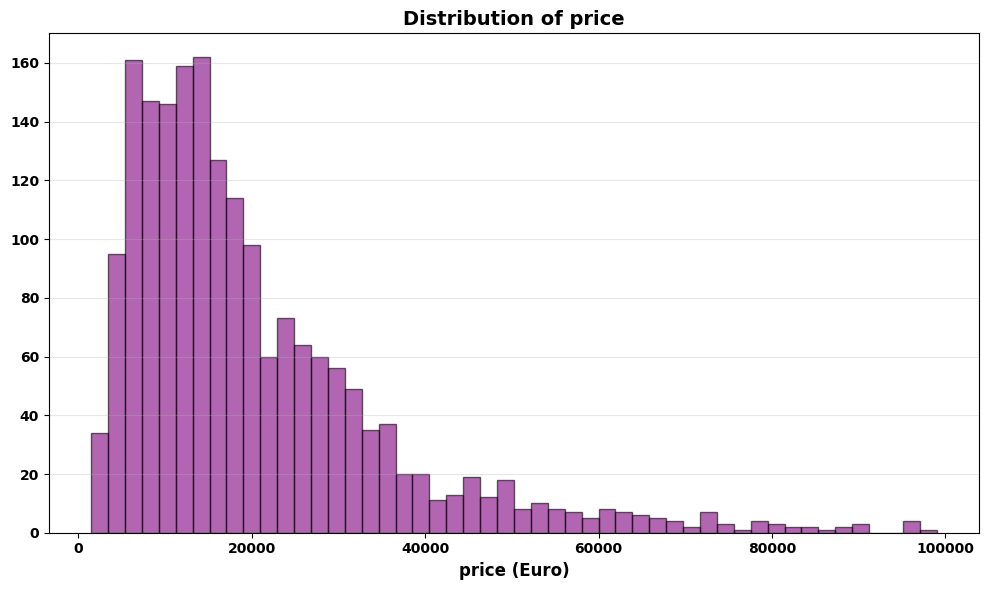

Skewness: 1.868


In [425]:
print(df['price'].describe())

plot_single_histogram(df, 'price', label='price (Euro)')
print(f"Skewness: {df['price'].skew():.3f}")

# # log transformed histogram
# print("Histogram for price after log-transform:")
# plot_single_histogram(df, 'price',  label='price (Euro)', log=True)

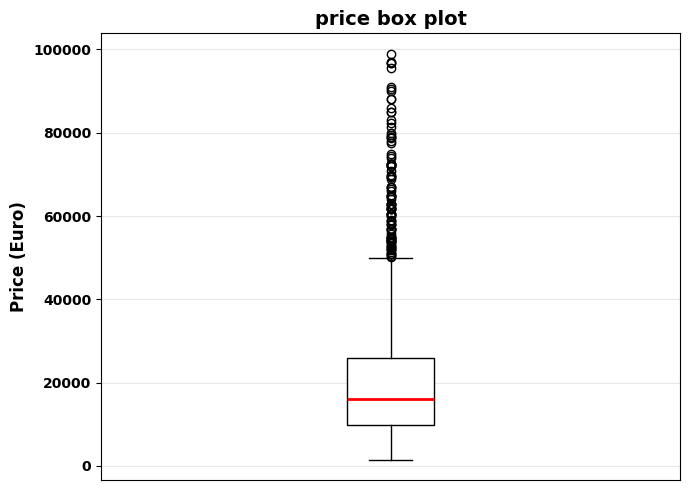

,price
Q1,9890.540000
Q3,26000.000000
IQR,16109.460000
lower_whisker,1500.000000
upper_whisker,50000.000000
min,1500.000000
max,99000.000000
mean,20299.769704
stdev,15456.815927


In [426]:
# price boxplot
plot_single_boxplot(df, 'price', title='Price (Euro)', figsize=(7, 5))
compute_boxplot_stats(df, ['price'])

In [427]:
# outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\nPrice outliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Outlier bounds: €{lower_bound:.0f} - €{upper_bound:.0f}")


Price outliers (IQR method): 104 (5.49%)
Outlier bounds: €-14274 - €50164


<!-- ##### 3.2 Numerical features -->

Descriptives

In [429]:
print("Descriptives of numerical features:")
df[numerical_cols].describe().T

Descriptives of numerical features:


,count,mean,std,min,25%,50%,75%,max
year,1893.0,2017.732699,4.083222,2006.0,2015.0,2019.0,2021.0,2025.0
mileage,1893.0,155202.957211,76445.088285,1000.0,99200.0,157000.0,209230.0,395000.0
engine_capacity,1893.0,1865.040676,512.133517,875.0,1498.0,1968.0,1996.0,3198.0
engine_power,1893.0,172.443212,68.796361,60.0,120.0,150.0,200.0,400.0


Visualize distribution of each numerical feature

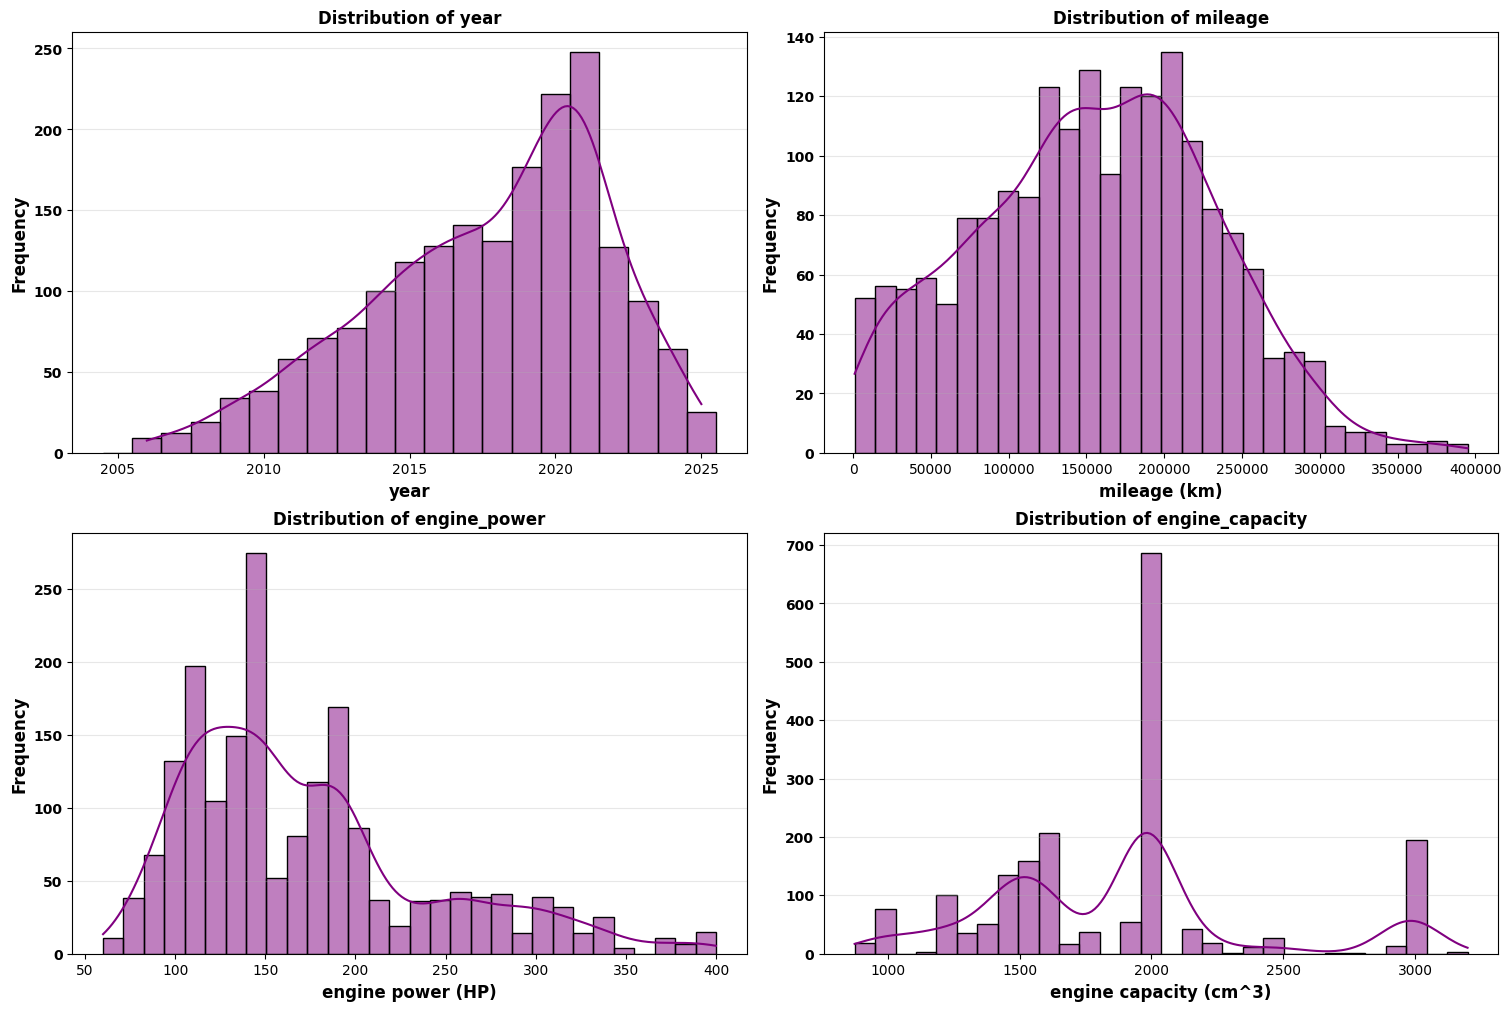

In [430]:
plot_histograms(df, ['year', 'mileage', 'engine_power', 'engine_capacity'], ['year', 'mileage (km)', 'engine power (HP)', 'engine capacity (cm^3)'])

In [242]:
# plot_numerical_feature_distribution(df, 'year', 'year', bin_width=1, figsize=(10, 6))

# plot_numerical_feature_distribution(df, 'mileage', 'mileage (km)', bin_width=10000, figsize=(10, 6))

# plot_numerical_feature_distribution(df, 'engine_power', 'engine power (HP)', bin_width=50, min_value=50, figsize=(10, 6))

# plot_numerical_feature_distribution(df, 'engine_capacity', 'engine capacity (cm^3)', bin_width=50, min_value=50, figsize=(10, 6))

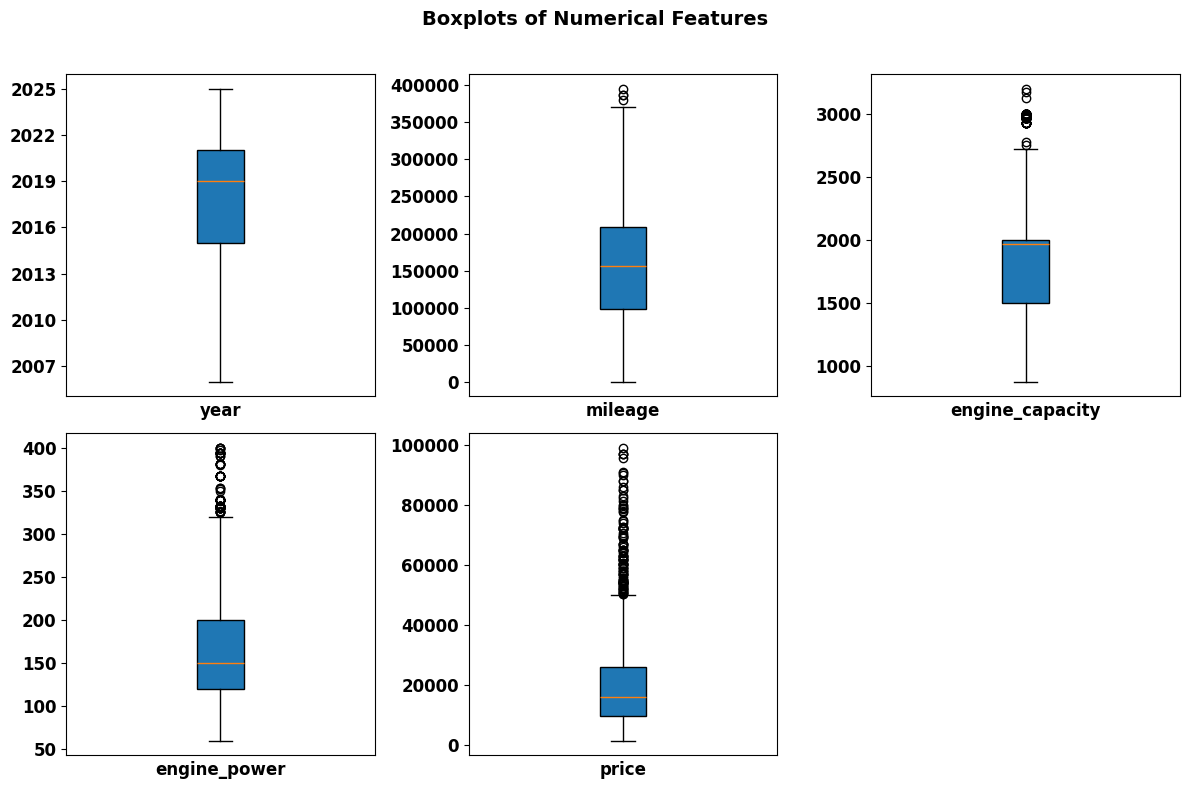

,year,mileage,engine_capacity,engine_power,price
Q1,2015.000000,99200.000000,1498.000000,120.000000,9890.540000
Q3,2021.000000,209230.000000,1996.000000,200.000000,26000.000000
IQR,6.000000,110030.000000,498.000000,80.000000,16109.460000
lower_whisker,2006.000000,1000.000000,875.000000,60.000000,1500.000000
upper_whisker,2025.000000,370000.000000,2720.000000,320.000000,50000.000000
min,2006.000000,1000.000000,875.000000,60.000000,1500.000000
max,2025.000000,395000.000000,3198.000000,400.000000,99000.000000
mean,2017.732699,155202.957211,1865.040676,172.443212,20299.769704
stdev,4.083222,76445.088285,512.133517,68.796361,15456.815927


In [431]:
create_boxplot(df, numerical_features, title="Boxplots of Numerical Features", num_rows=2, figsize=(12, 8))
compute_boxplot_stats(df, numerical_features)

##### 3.3 Categorical features

Make

Unique values for make: 42


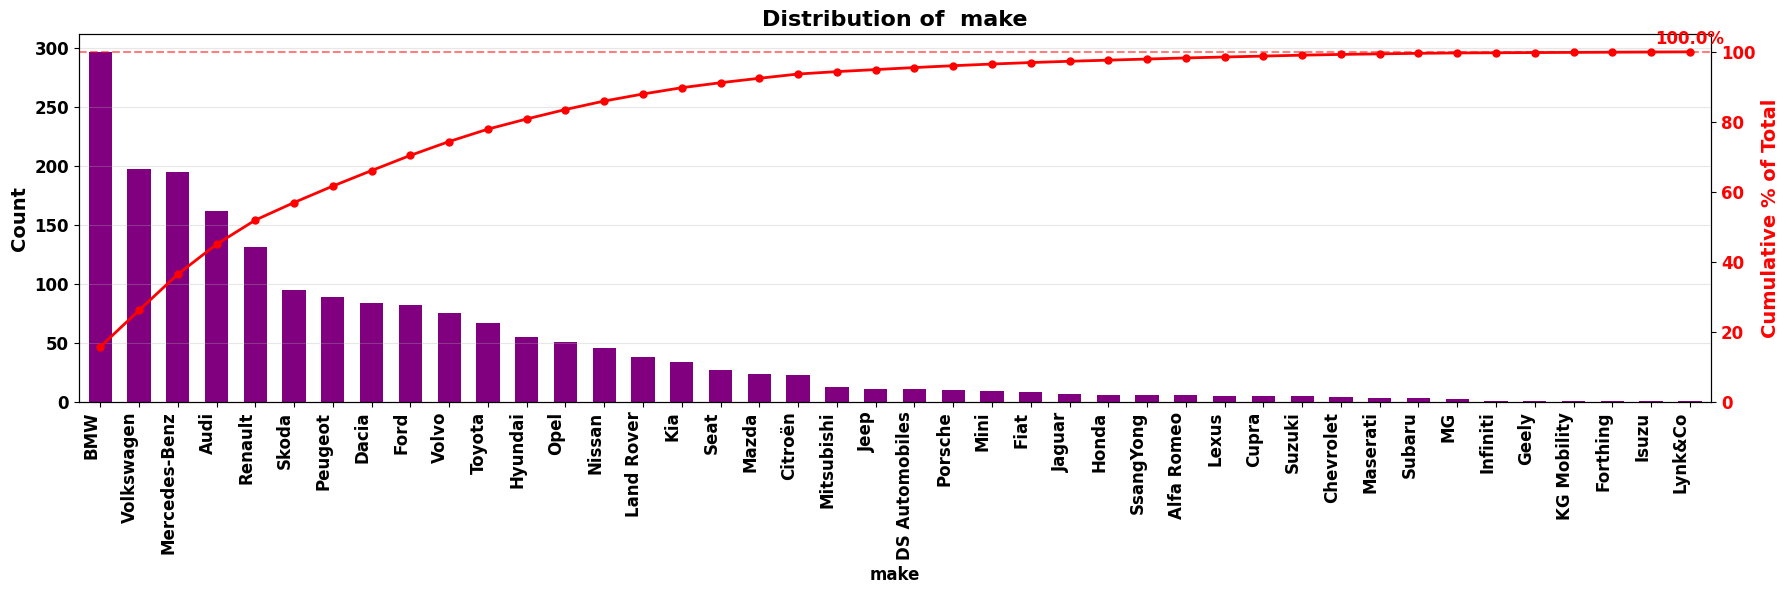

In [440]:
print(f"Unique values for make: {df['make'].nunique()}")
# print(df['make'].value_counts())
plot_categorical_feature(df, 'make', figsize=(18, 6))

Model

Unique values for model: 288


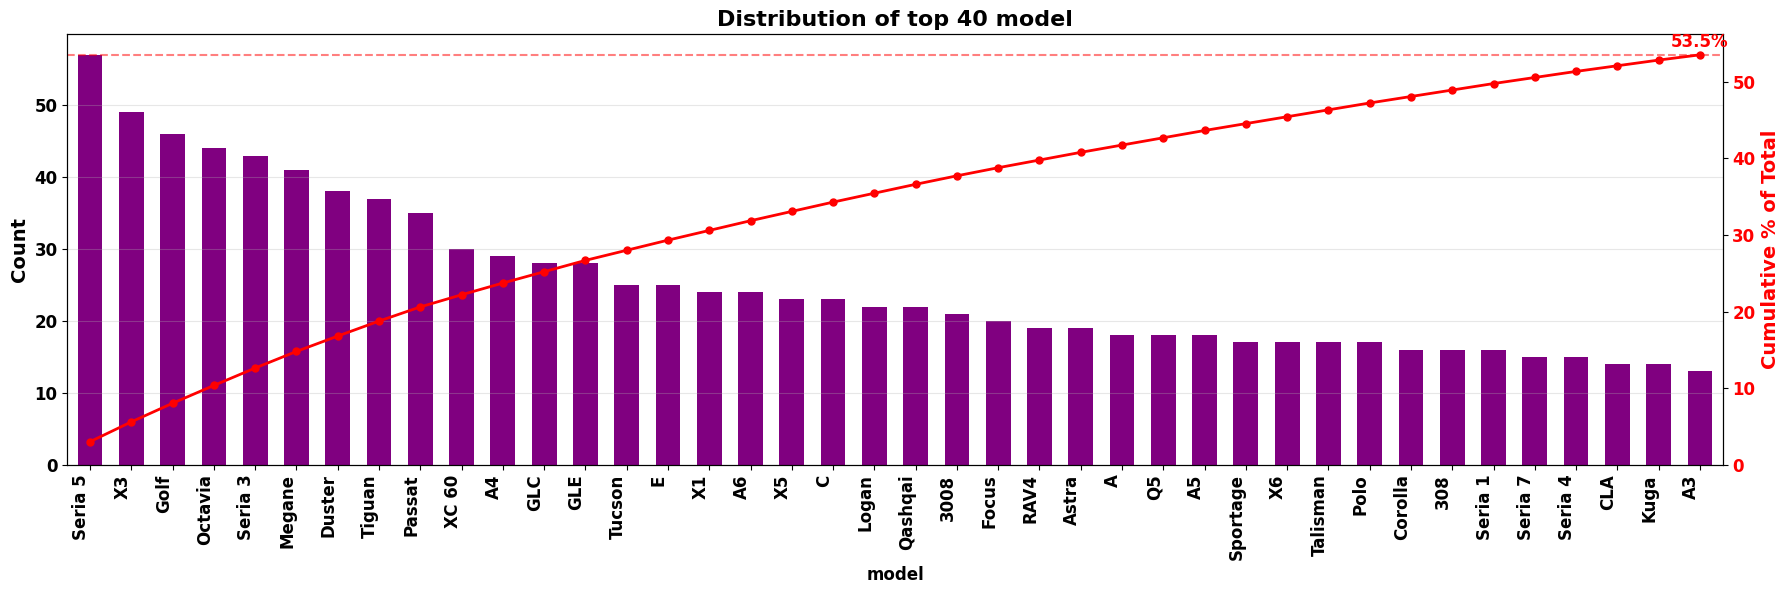

In [441]:
print(f"Unique values for model: {df['model'].nunique()}")
# print(df['model'].value_counts())
plot_categorical_feature(df, 'model', figsize=(18, 6), top_n=40)

Body type

Unique values for body_type: 9


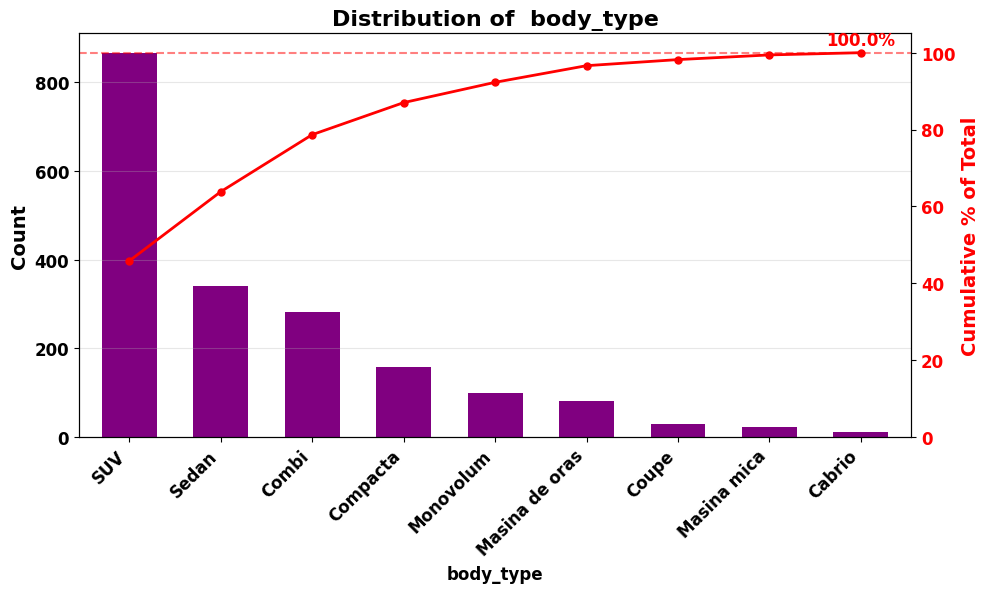

In [442]:
print(f"Unique values for body_type: {df['body_type'].nunique()}")
plot_categorical_feature(df, 'body_type', figsize=(10, 6), rotation=45)

Color

Unique values for color: 12


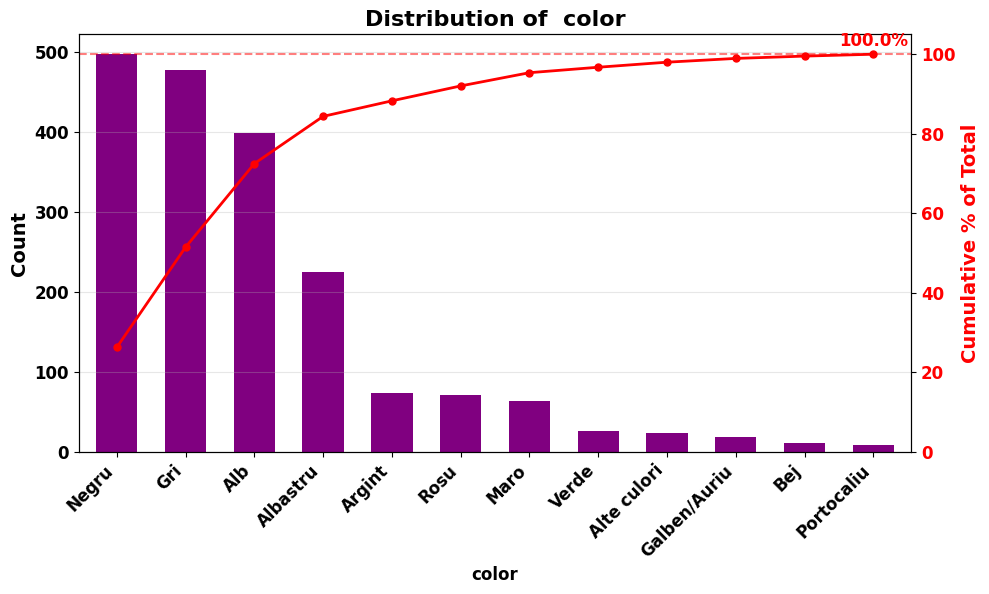

In [443]:
print(f"Unique values for color: {df['color'].nunique()}")
plot_categorical_feature(df, 'color', figsize=(10, 6), rotation=45)

Fuel type

Unique values for fuel_type: 5


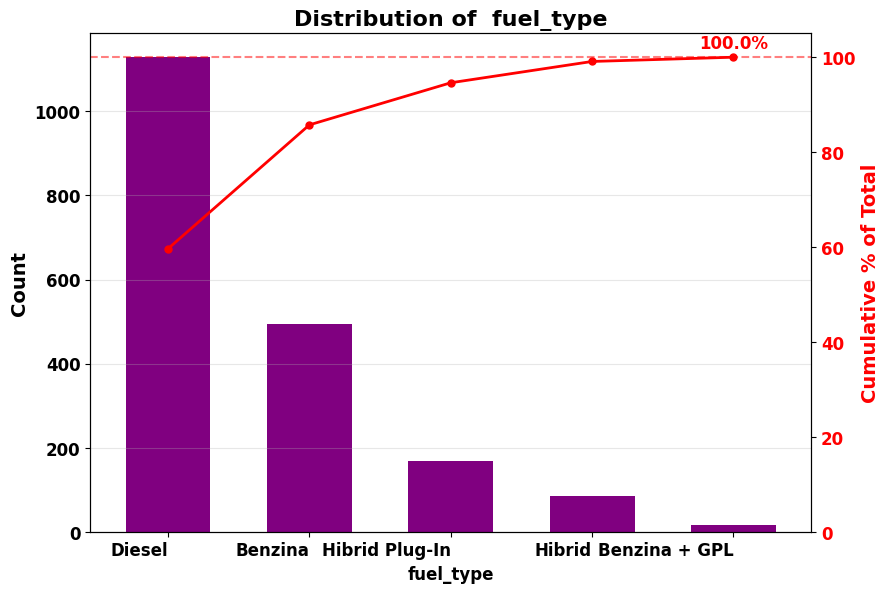

In [444]:
print(f"Unique values for fuel_type: {df['fuel_type'].nunique()}")
plot_categorical_feature(df, 'fuel_type', figsize=(9, 6), rotation=0)

Gearbox

Unique values for gearbox: 2


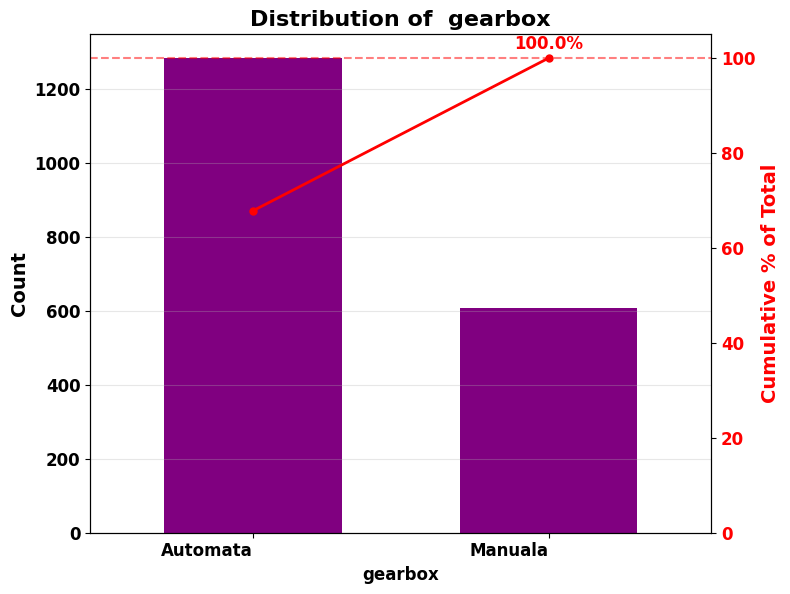

In [445]:
print(f"Unique values for gearbox: {df['gearbox'].nunique()}")
plot_categorical_feature(df, 'gearbox', figsize=(8, 6), rotation=0)

Transmission

Unique values for transmission: 4


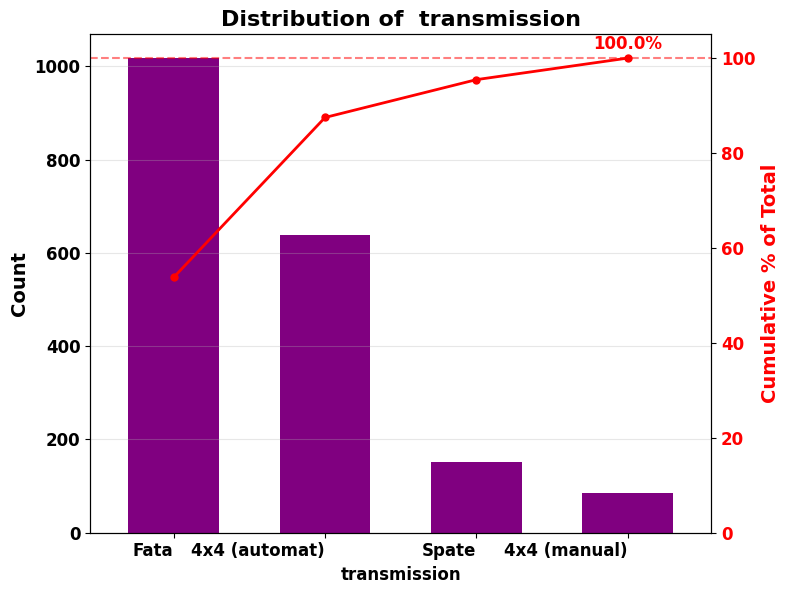

In [446]:
print(f"Unique values for transmission: {df['transmission'].nunique()}")
plot_categorical_feature(df, 'transmission', figsize=(8, 6), rotation=0)

Pollution standard

Unique values for pollution_standard: 9


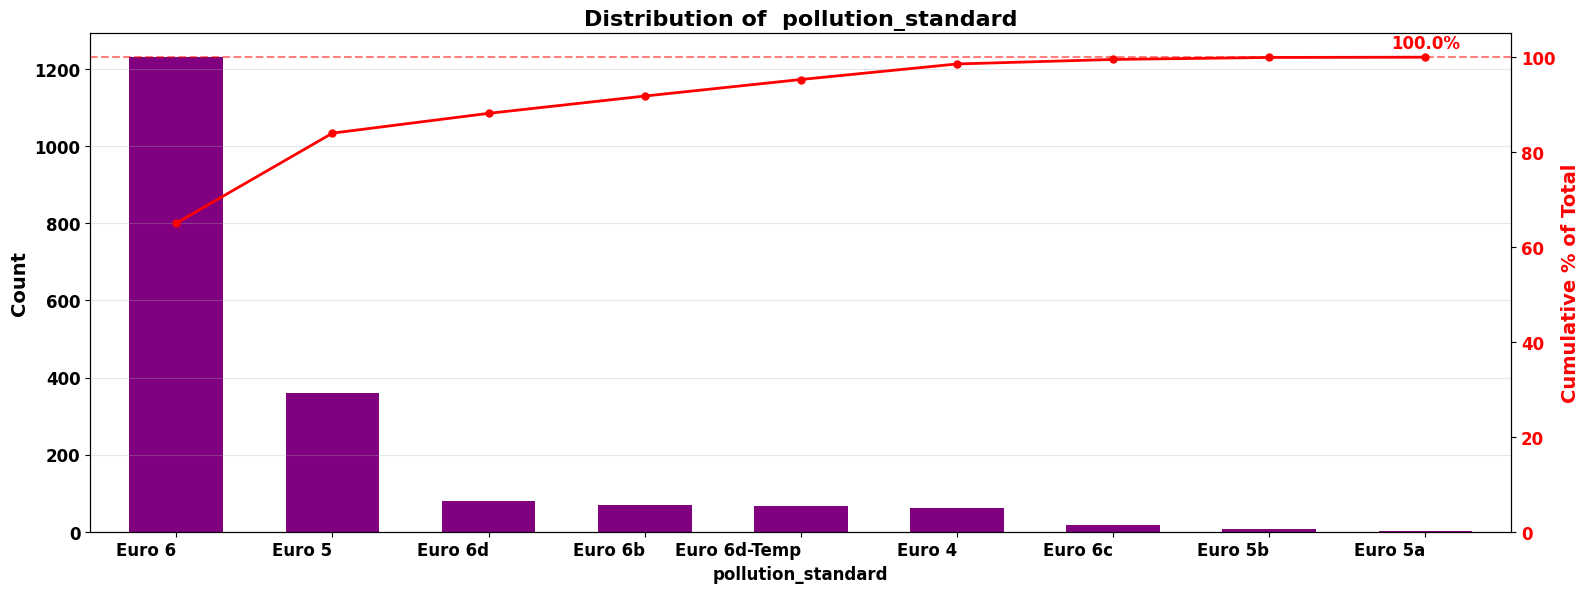

In [447]:
print(f"Unique values for pollution_standard: {df['pollution_standard'].nunique()}")
plot_categorical_feature(df, 'pollution_standard', figsize=(16, 6), rotation=0)

#### 4. Bivariate analysis

##### 4.1 Correlations

Correlation with price (for numerical features):
price              1.000000
engine_power       0.692044
year               0.613666
engine_capacity    0.503567
mileage           -0.547159
Name: price, dtype: float64


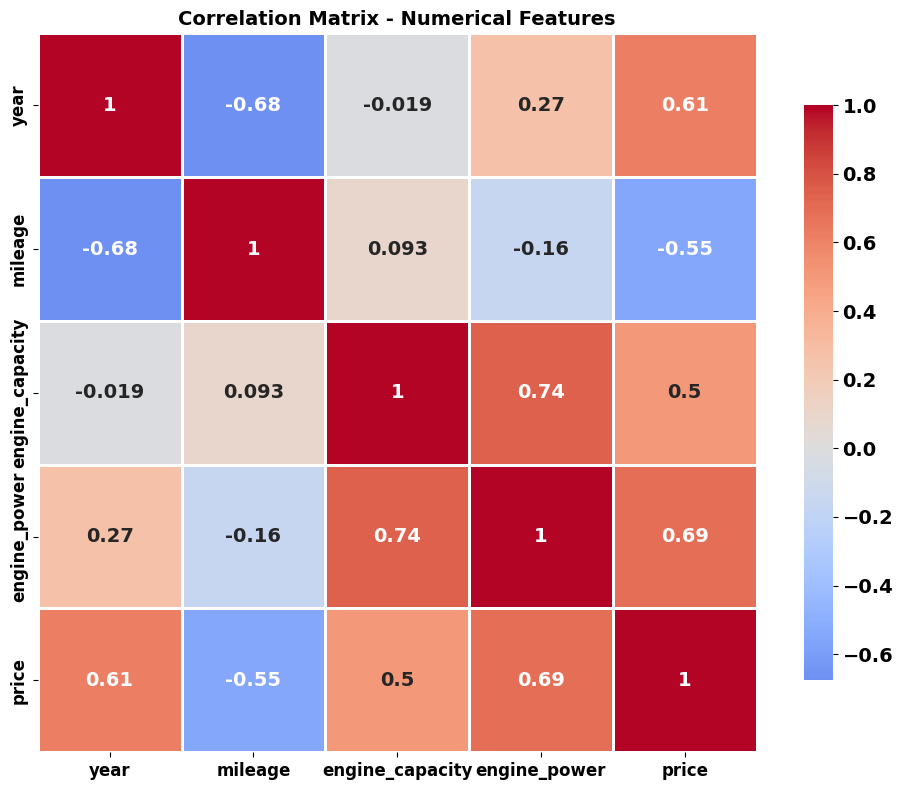

In [485]:
# Correlation with price
print("Correlation with price (for numerical features):")
numerical_features = ['year', 'mileage', 'engine_capacity', 'engine_power']
correlations = df[numerical_features + ['price']].corr()['price'].sort_values(ascending=False)
print(correlations)

# Full correlation matrix
corr_matrix = df[numerical_features + ['price']].corr()

# Heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, annot_kws={'weight': 'bold', 'size': 14})
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
for t in cbar.ax.get_yticklabels():
    t.set_fontweight('bold') \

plt.tight_layout()
plt.show()

##### 4.2 Numerical features vs price

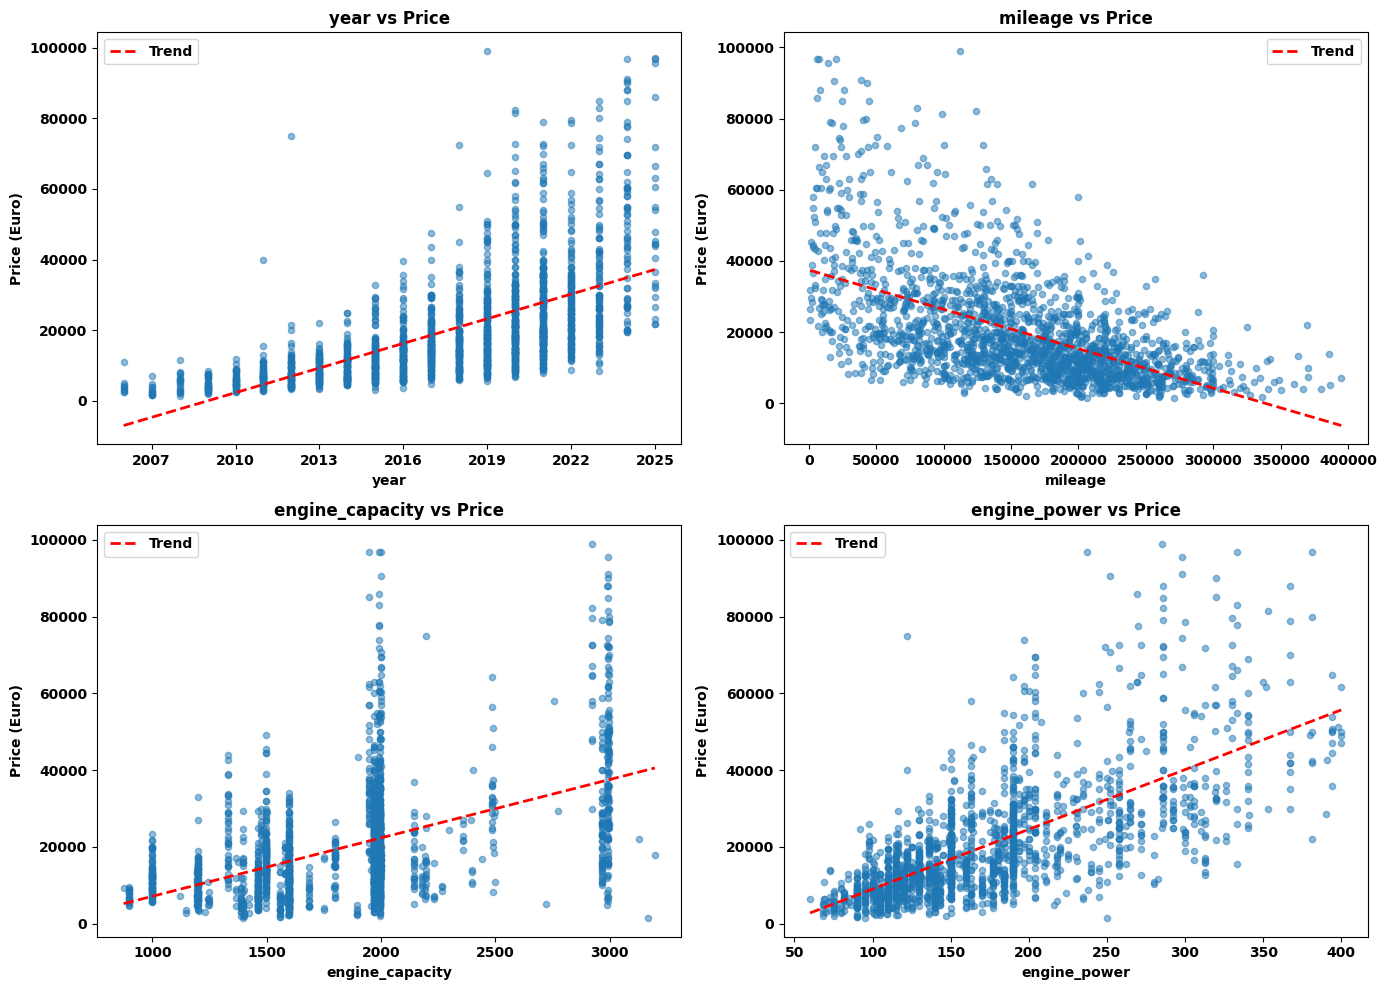

In [464]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    if idx >= len(axes): break
    
    axes[idx].scatter(df[col], df['price'], alpha=0.5, s=20)
    
    z = np.polyfit(df[col], df['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, label='Trend')
    
    axes[idx].set_xlabel(col, fontweight='bold')
    axes[idx].set_ylabel('Price (Euro)', fontweight='bold')
    axes[idx].set_title(f'{col} vs Price', fontweight='bold')
    
    axes[idx].legend(prop={'weight': 'bold'})
    plt.setp(axes[idx].get_xticklabels(), fontweight="bold")
    plt.setp(axes[idx].get_yticklabels(), fontweight="bold")

    if 'year' in col.lower():
        axes[idx].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


##### 4.3 Price by categorical features

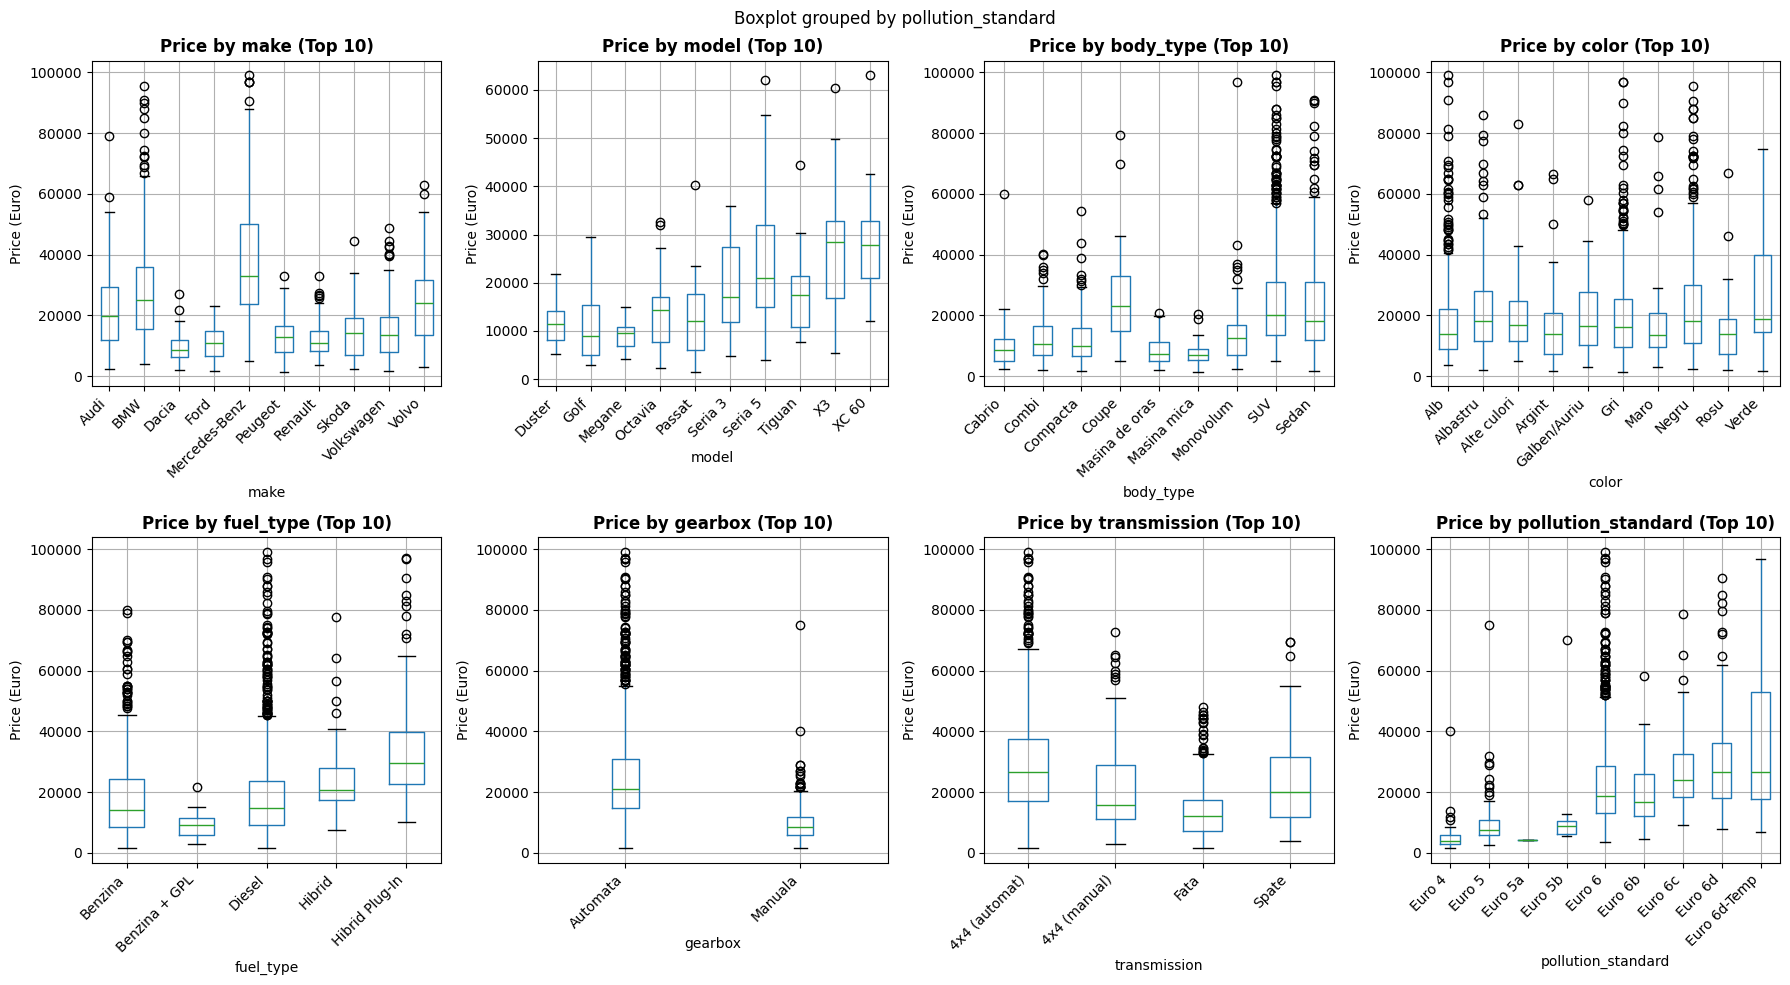

Mean price by category

make:
                       mean     median  count
make                                         
Maserati       48830.000000  48490.000      3
Lexus          47221.204000  45989.680      5
Isuzu          43489.820000  43489.820      1
Mercedes-Benz  38316.315590  32890.220    195
Geely          36500.000000  36500.000      1
Porsche        35441.388000  27150.105     10
Cupra          31851.476000  26450.000      5
Forthing       28998.860000  28998.860      1
BMW            28394.495455  24990.000    297
Land Rover     27464.243158  19945.000     38

model:
                       mean     median  count
model                                        
G              99000.000000  99000.000      1
AMG            69950.000000  69950.000      1
X6 M           61750.000000  61750.000      1
Cayenne Coupe  61422.335000  61422.335      2
GLE            60861.742143  62093.950     28
Defender       60634.265000  63819.030      4
Seria RX       60313.180000  60313.180    

In [473]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    top_10_categories = df[col].value_counts().nlargest(10).index
    
    df_filtered = df[df[col].isin(top_10_categories)]
    df_filtered.boxplot(column='price', by=col, ax=axes[idx])
    
    axes[idx].set_title(f'Price by {col} (Top 10)', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Price (Euro)')
    
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Mean price by category")
for col in categorical_features:
    mean_price = df.groupby(col)['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    print(f"\n{col}:")
    print(mean_price.head(10))

<Figure size 1800x600 with 0 Axes>

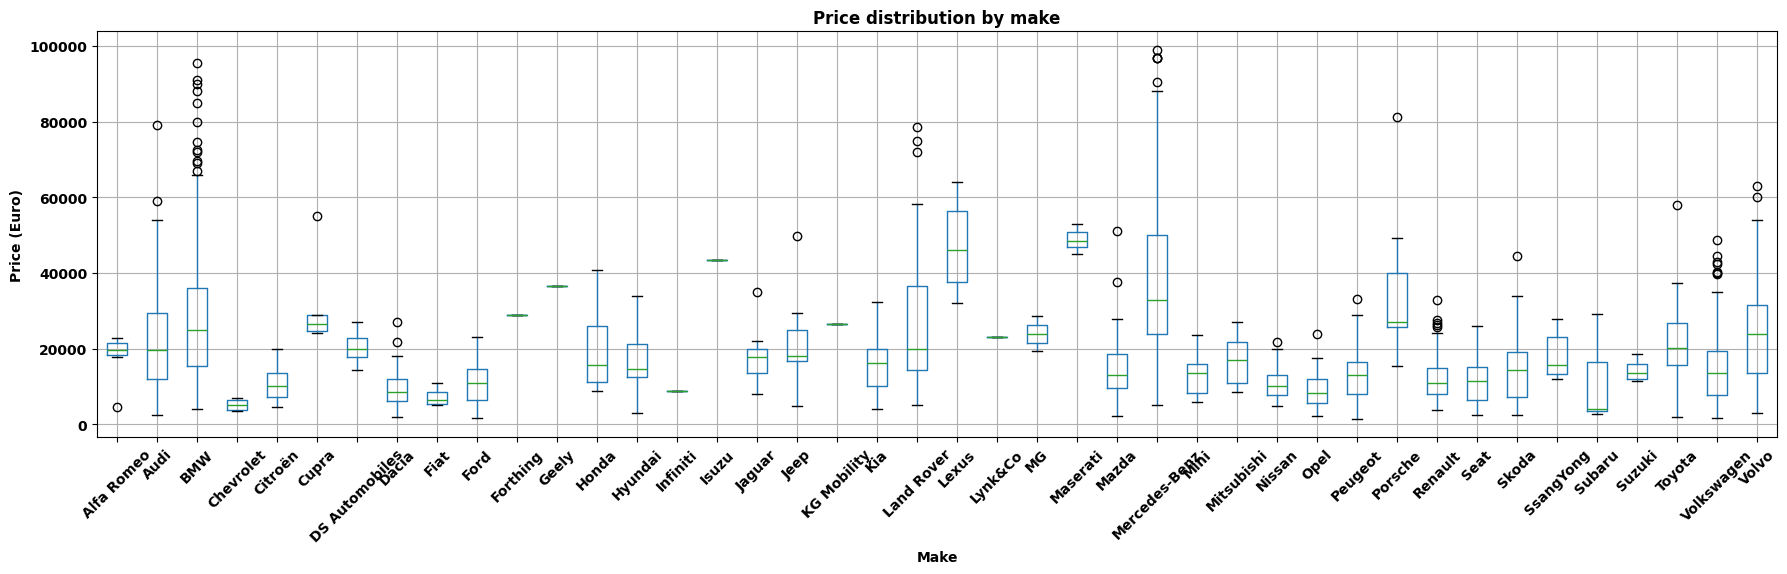

In [479]:
plt.figure(figsize=(18, 6))

df.boxplot(column='price', by='make', figsize=(18, 6))

plt.title('Price distribution by make', fontweight='bold')
plt.suptitle("")
plt.xlabel('Make', fontweight='bold')
plt.ylabel('Price (Euro)', fontweight='bold')
plt.xticks(rotation=45, fontweight='bold')
plt.yticks(fontweight='bold')

plt.tight_layout()
plt.show()